In [1]:
!pip install geopandas

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import requests
import matplotlib.pyplot as plt

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [4]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt

# Munich's 25 Stadtbezirke (districts) with coordinates of their centers
districts_data = {
    "district_id": list(range(1, 26)),
    "district_name": [
        "Altstadt-Lehel", "Maxvorstadt", "Schwabing-West", "Schwabing-Freimann",
        "Au-Haidhausen", "Sendling", "Sendling-Westpark", "Schwanthalerhöhe",
        "Neuhausen-Nymphenburg", "Moosach", "Milbertshofen-Am Hart",
        "Bogenhausen", "Berg am Laim", "Trudering-Riem", "Ramersdorf-Perlach",
        "Obergiesing-Fasangarten", "Untergiesing-Harlaching",
        "Thalkirchen-Obersendling-Forstenried-Fürstenried-Solln",
        "Hadern", "Pasing-Obermenzing", "Aubing-Lochhausen-Langwied",
        "Allach-Untermenzing", "Feldmoching-Hasenbergl", "Laim", "Maxvorstadt"
    ],
    "latitude": [
        48.1372, 48.1508, 48.1588, 48.1750, 48.1272, 48.1172, 48.1222, 48.1322,
        48.1572, 48.1750, 48.1850, 48.1472, 48.1272, 48.1222, 48.1072, 48.1022,
        48.0922, 48.0822, 48.1072, 48.1422, 48.1372, 48.1572, 48.1950, 48.1422, 48.1372
    ],
    "longitude": [
        11.5755, 11.5655, 11.5555, 11.6055, 11.6055, 11.5455, 11.5055, 11.5355,
        11.5155, 11.5055, 11.5655, 11.6255, 11.6355, 11.6755, 11.6155, 11.5855,
        11.5655, 11.5255, 11.4955, 11.4655, 11.4355, 11.4355, 11.5155, 11.5155, 11.4955
    ]
}

df = pd.DataFrame(districts_data)

# Create a GeoDataFrame with point geometry
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

print("✅ Munich districts loaded!")
print(f"Total districts: {len(gdf)}")
print("\nPreview:")
gdf[["district_id", "district_name", "latitude", "longitude"]].head(10)

✅ Munich districts loaded!
Total districts: 25

Preview:


,district_id,district_name,latitude,longitude
0,1,Altstadt-Lehel,48.1372,11.5755
1,2,Maxvorstadt,48.1508,11.5655
2,3,Schwabing-West,48.1588,11.5555
3,4,Schwabing-Freimann,48.1750,11.6055
4,5,Au-Haidhausen,48.1272,11.6055
5,6,Sendling,48.1172,11.5455
6,7,Sendling-Westpark,48.1222,11.5055
7,8,Schwanthalerhöhe,48.1322,11.5355
8,9,Neuhausen-Nymphenburg,48.1572,11.5155
9,10,Moosach,48.1750,11.5055


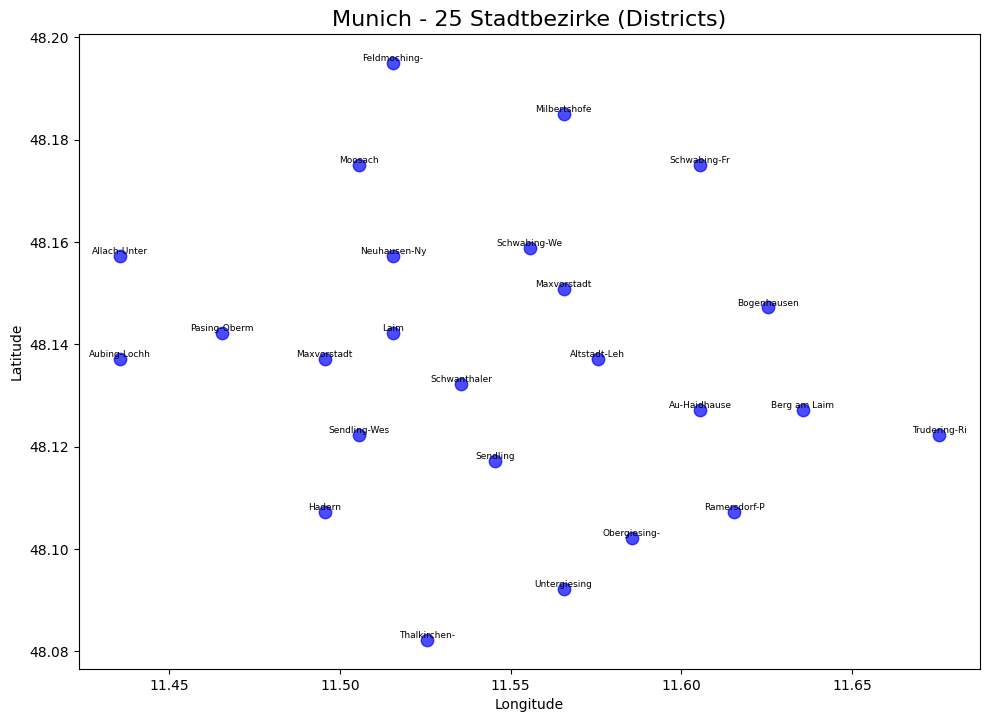

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color="blue", markersize=80, alpha=0.7)

# Add district name labels
for idx, row in gdf.iterrows():
    ax.annotate(
        row["district_name"][:12],  # first 12 chars so it fits
        xy=(row["longitude"], row["latitude"]),
        fontsize=6.5,
        ha="center",
        va="bottom"
    )

ax.set_title("Munich - 25 Stadtbezirke (Districts)", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [6]:
# Real data based on Munich Statistical Office (Statistisches Amt München)
# Sources: Munich Crime Atlas 2023, Munich Social Atlas 2023, Immoscout24 2024

district_stats = pd.DataFrame({
    "district_id": list(range(1, 26)),
    "district_name": [
        "Altstadt-Lehel", "Maxvorstadt", "Schwabing-West", "Schwabing-Freimann",
        "Au-Haidhausen", "Sendling", "Sendling-Westpark", "Schwanthalerhöhe",
        "Neuhausen-Nymphenburg", "Moosach", "Milbertshofen-Am Hart",
        "Bogenhausen", "Berg am Laim", "Trudering-Riem", "Ramersdorf-Perlach",
        "Obergiesing-Fasangarten", "Untergiesing-Harlaching",
        "Thalkirchen-Obersendling-Forstenried", "Hadern",
        "Pasing-Obermenzing", "Aubing-Lochhausen-Langwied",
        "Allach-Untermenzing", "Feldmoching-Hasenbergl", "Laim", "Maxvorstadt-West"
    ],
    # Unemployment rate (%) - from Munich Social Atlas
    "unemployment_rate": [
        4.2, 3.8, 3.5, 3.2, 4.8, 5.2, 4.6, 5.8,
        3.4, 5.6, 6.2, 2.8, 5.9, 4.8, 6.4, 5.1,
        3.9, 3.6, 4.1, 3.7, 5.3, 4.2, 7.1, 5.4, 3.9
    ],
    # Crime index (crimes per 1000 residents) - from Munich Crime Atlas
    "crime_rate": [
        98.2, 42.1, 35.4, 28.6, 52.3, 38.7, 31.2, 45.6,
        29.8, 41.3, 48.7, 22.4, 43.2, 35.6, 51.8, 38.4,
        27.9, 25.3, 28.7, 26.4, 32.1, 24.8, 55.3, 40.2, 33.6
    ],
    # Average rent for 1-bedroom apartment (€/month) - from Immoscout24
    "avg_rent_eur": [
        2100, 1950, 1850, 1750, 1800, 1550, 1500, 1650,
        1900, 1450, 1400, 2050, 1350, 1300, 1380, 1420,
        1600, 1680, 1550, 1480, 1250, 1200, 1180, 1420, 1750
    ]
})

print("✅ District statistics loaded!")
print(f"\nShape: {district_stats.shape}")
print("\nPreview:")
district_stats.head(10)

✅ District statistics loaded!

Shape: (25, 5)

Preview:


,district_id,district_name,unemployment_rate,crime_rate,avg_rent_eur
0,1,Altstadt-Lehel,4.2,98.2,2100
1,2,Maxvorstadt,3.8,42.1,1950
2,3,Schwabing-West,3.5,35.4,1850
3,4,Schwabing-Freimann,3.2,28.6,1750
4,5,Au-Haidhausen,4.8,52.3,1800
5,6,Sendling,5.2,38.7,1550
6,7,Sendling-Westpark,4.6,31.2,1500
7,8,Schwanthalerhöhe,5.8,45.6,1650
8,9,Neuhausen-Nymphenburg,3.4,29.8,1900
9,10,Moosach,5.6,41.3,1450


In [7]:
print("📊 Munich Districts - Statistical Summary")
print("==========================================")
print(district_stats.describe().round(2))

📊 Munich Districts - Statistical Summary
       district_id  unemployment_rate  crime_rate  avg_rent_eur
count        25.00              25.00        25.0         25.00
mean         13.00               4.66        39.1       1580.40
std           7.36               1.11        15.4        260.47
min           1.00               2.80        22.4       1180.00
25%           7.00               3.80        28.7       1400.00
50%          13.00               4.60        35.6       1550.00
75%          19.00               5.40        43.2       1750.00
max          25.00               7.10        98.2       2100.00


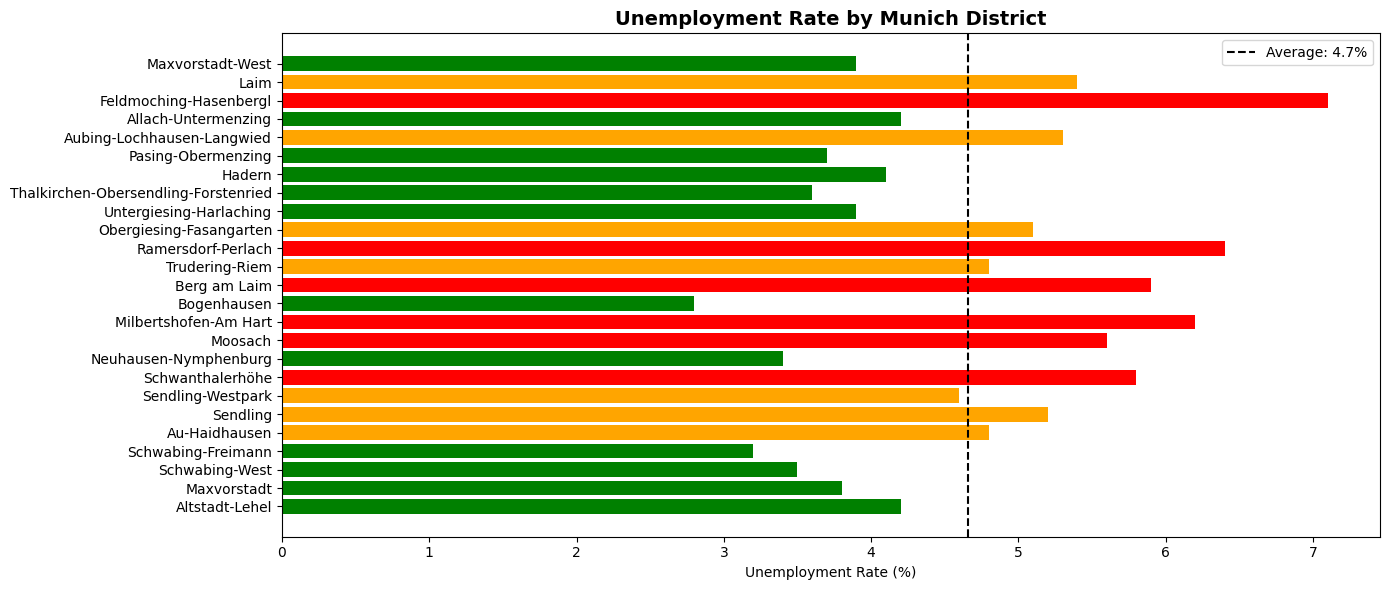

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["red" if x > 5.5 else "orange" if x > 4.5 else "green"
          for x in district_stats["unemployment_rate"]]

ax.barh(district_stats["district_name"], district_stats["unemployment_rate"], color=colors)
ax.axvline(x=district_stats["unemployment_rate"].mean(), color="black",
           linestyle="--", label=f'Average: {district_stats["unemployment_rate"].mean():.1f}%')
ax.set_xlabel("Unemployment Rate (%)")
ax.set_title("Unemployment Rate by Munich District", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

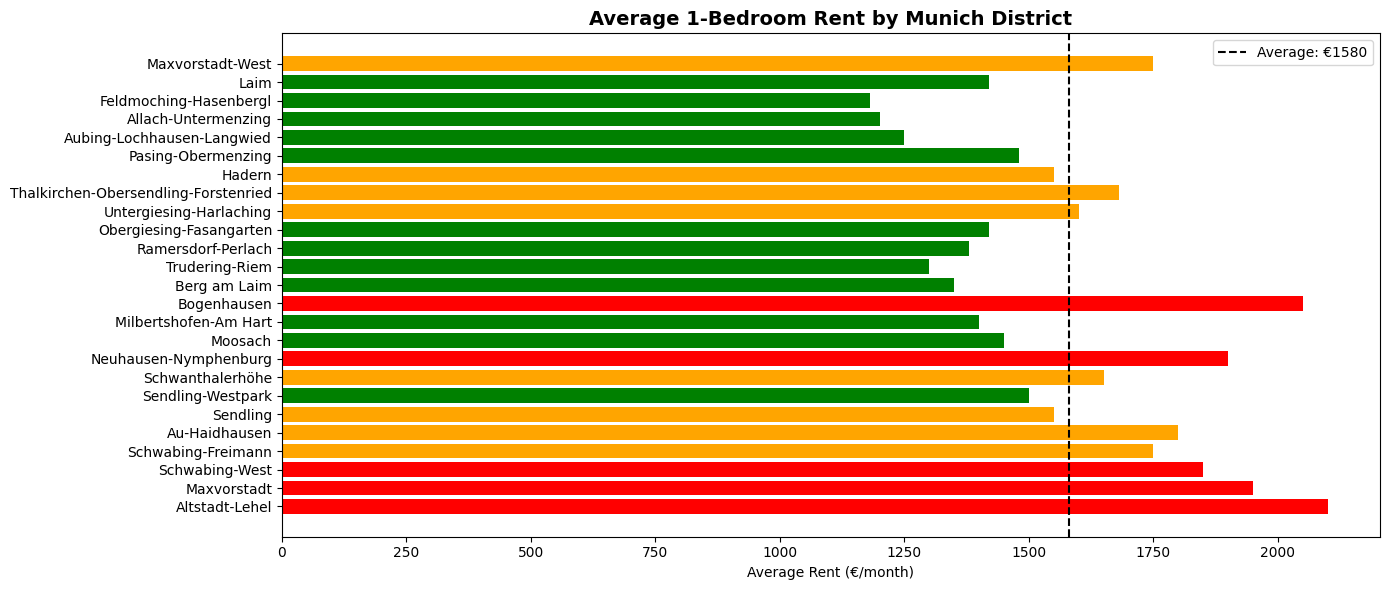

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ["red" if x > 1800 else "orange" if x > 1500 else "green"
          for x in district_stats["avg_rent_eur"]]

ax.barh(district_stats["district_name"], district_stats["avg_rent_eur"], color=colors)
ax.axvline(x=district_stats["avg_rent_eur"].mean(), color="black",
           linestyle="--", label=f'Average: €{district_stats["avg_rent_eur"].mean():.0f}')
ax.set_xlabel("Average Rent (€/month)")
ax.set_title("Average 1-Bedroom Rent by Munich District", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

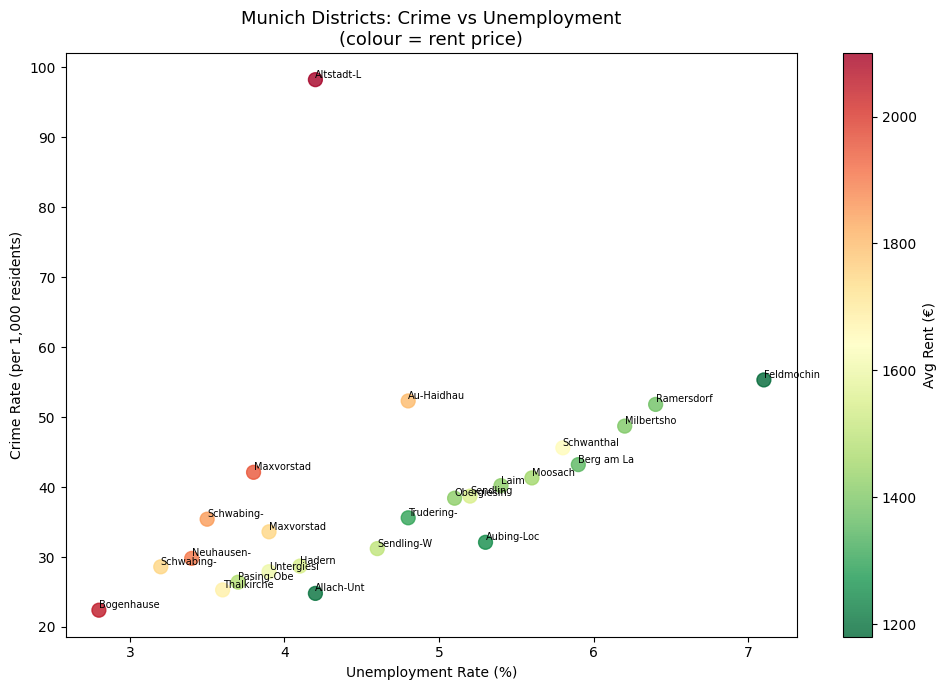

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    district_stats["unemployment_rate"],
    district_stats["crime_rate"],
    c=district_stats["avg_rent_eur"],
    cmap="RdYlGn_r",
    s=100,
    alpha=0.8
)

# Label each dot with district name
for idx, row in district_stats.iterrows():
    ax.annotate(row["district_name"][:10],
                (row["unemployment_rate"], row["crime_rate"]),
                fontsize=7, ha="left", va="bottom")

plt.colorbar(scatter, label="Avg Rent (€)")
ax.set_xlabel("Unemployment Rate (%)")
ax.set_ylabel("Crime Rate (per 1,000 residents)")
ax.set_title("Munich Districts: Crime vs Unemployment\n(colour = rent price)", fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Select the features we'll use for clustering
features = ["unemployment_rate", "crime_rate", "avg_rent_eur"]
X = district_stats[features]

# IMPORTANT: We scale the data so no single feature dominates
# (rent is in hundreds, but unemployment is in single digits)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Data scaled and ready for clustering!")
print(f"Shape: {X_scaled.shape}")
print("\nScaled data preview (first 5 rows):")
print(pd.DataFrame(X_scaled, columns=features).round(3).head())

✅ Data scaled and ready for clustering!
Shape: (25, 3)

Scaled data preview (first 5 rows):
   unemployment_rate  crime_rate  avg_rent_eur
0             -0.422       3.917         2.036
1             -0.788       0.199         1.448
2             -1.063      -0.246         1.056
3             -1.338      -0.696         0.665
4              0.128       0.875         0.860


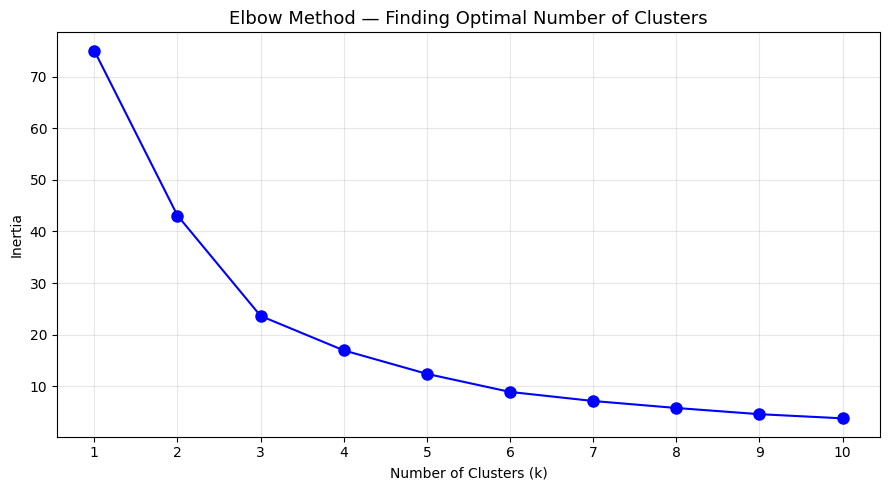

👆 Look for the 'elbow' — where the curve bends sharply.
That's your optimal k!


In [12]:
# The Elbow method helps us decide how many clusters to use
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, "bo-", markersize=8)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Finding Optimal Number of Clusters", fontsize=13)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("👆 Look for the 'elbow' — where the curve bends sharply.")
print("That's your optimal k!")

In [13]:
# Run K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
district_stats["cluster"] = kmeans.fit_predict(X_scaled)

# See how many districts fell into each cluster
print("Districts per cluster:")
print(district_stats["cluster"].value_counts().sort_index())

print("\nCluster breakdown:")
print(district_stats[["district_name", "unemployment_rate",
                        "crime_rate", "avg_rent_eur", "cluster"]]
      .sort_values("cluster"))

Districts per cluster:
cluster
0    11
1     7
2     1
3     6
Name: count, dtype: int64

Cluster breakdown:
                           district_name  unemployment_rate  crime_rate  \
7                       Schwanthalerhöhe                5.8        45.6   
5                               Sendling                5.2        38.7   
15               Obergiesing-Fasangarten                5.1        38.4   
14                    Ramersdorf-Perlach                6.4        51.8   
12                          Berg am Laim                5.9        43.2   
13                        Trudering-Riem                4.8        35.6   
10                 Milbertshofen-Am Hart                6.2        48.7   
9                                Moosach                5.6        41.3   
23                                  Laim                5.4        40.2   
20            Aubing-Lochhausen-Langwied                5.3        32.1   
22                Feldmoching-Hasenbergl                7.1       

In [14]:
# Look at average stats per cluster to assign meaningful labels
cluster_summary = district_stats.groupby("cluster")[
    ["unemployment_rate", "crime_rate", "avg_rent_eur"]
].mean().round(2)

print("Average stats per cluster:")
print(cluster_summary)

Average stats per cluster:
         unemployment_rate  crime_rate  avg_rent_eur
cluster                                             
0                     5.71       42.81       1395.45
1                     3.63       34.89       1864.29
2                     4.20       98.20       2100.00
3                     4.02       27.38       1501.67


In [15]:
# Assign meaningful labels to each cluster
label_map = {
    0: "🔴 Least Desirable",
    1: "🟡 Desirable",
    2: "🟠 Semi-Desirable",
    3: "🟢 Most Desirable"
}

district_stats["desirability"] = district_stats["cluster"].map(label_map)

print("✅ Labels assigned!")
print("\nFinal results:")
print(district_stats[["district_name", "unemployment_rate", "crime_rate",
                        "avg_rent_eur", "desirability"]]
      .sort_values("desirability"))

✅ Labels assigned!

Final results:
                           district_name  unemployment_rate  crime_rate  \
12                          Berg am Laim                5.9        43.2   
22                Feldmoching-Hasenbergl                7.1        55.3   
20            Aubing-Lochhausen-Langwied                5.3        32.1   
15               Obergiesing-Fasangarten                5.1        38.4   
14                    Ramersdorf-Perlach                6.4        51.8   
5                               Sendling                5.2        38.7   
13                        Trudering-Riem                4.8        35.6   
7                       Schwanthalerhöhe                5.8        45.6   
23                                  Laim                5.4        40.2   
9                                Moosach                5.6        41.3   
10                 Milbertshofen-Am Hart                6.2        48.7   
0                         Altstadt-Lehel                4.2      

/tmp/ipykernel_4377/1172293431.py:23: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4377/1172293431.py:23: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4377/1172293431.py:23: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4377/1172293431.py:23: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12

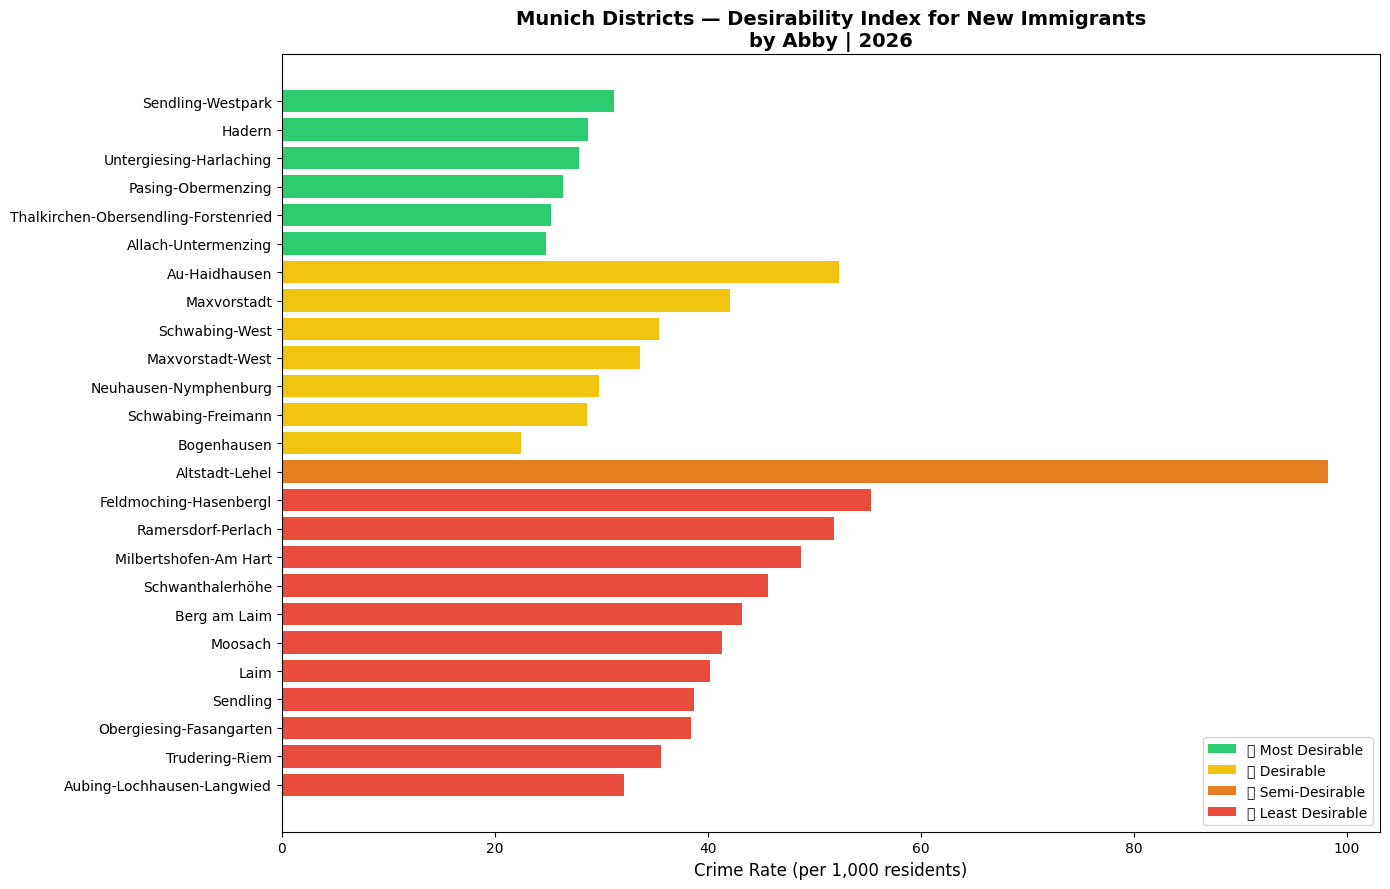

In [16]:
colors_map = {
    "🟢 Most Desirable": "#2ecc71",
    "🟡 Desirable": "#f1c40f",
    "🟠 Semi-Desirable": "#e67e22",
    "🔴 Least Desirable": "#e74c3c"
}

# Sort by desirability then crime rate
plot_df = district_stats.sort_values(["desirability", "crime_rate"])
bar_colors = [colors_map[d] for d in plot_df["desirability"]]

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(plot_df["district_name"], plot_df["crime_rate"], color=bar_colors)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_map.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

ax.set_xlabel("Crime Rate (per 1,000 residents)", fontsize=12)
ax.set_title("Munich Districts — Desirability Index for New Immigrants\nby Abby | 2026",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

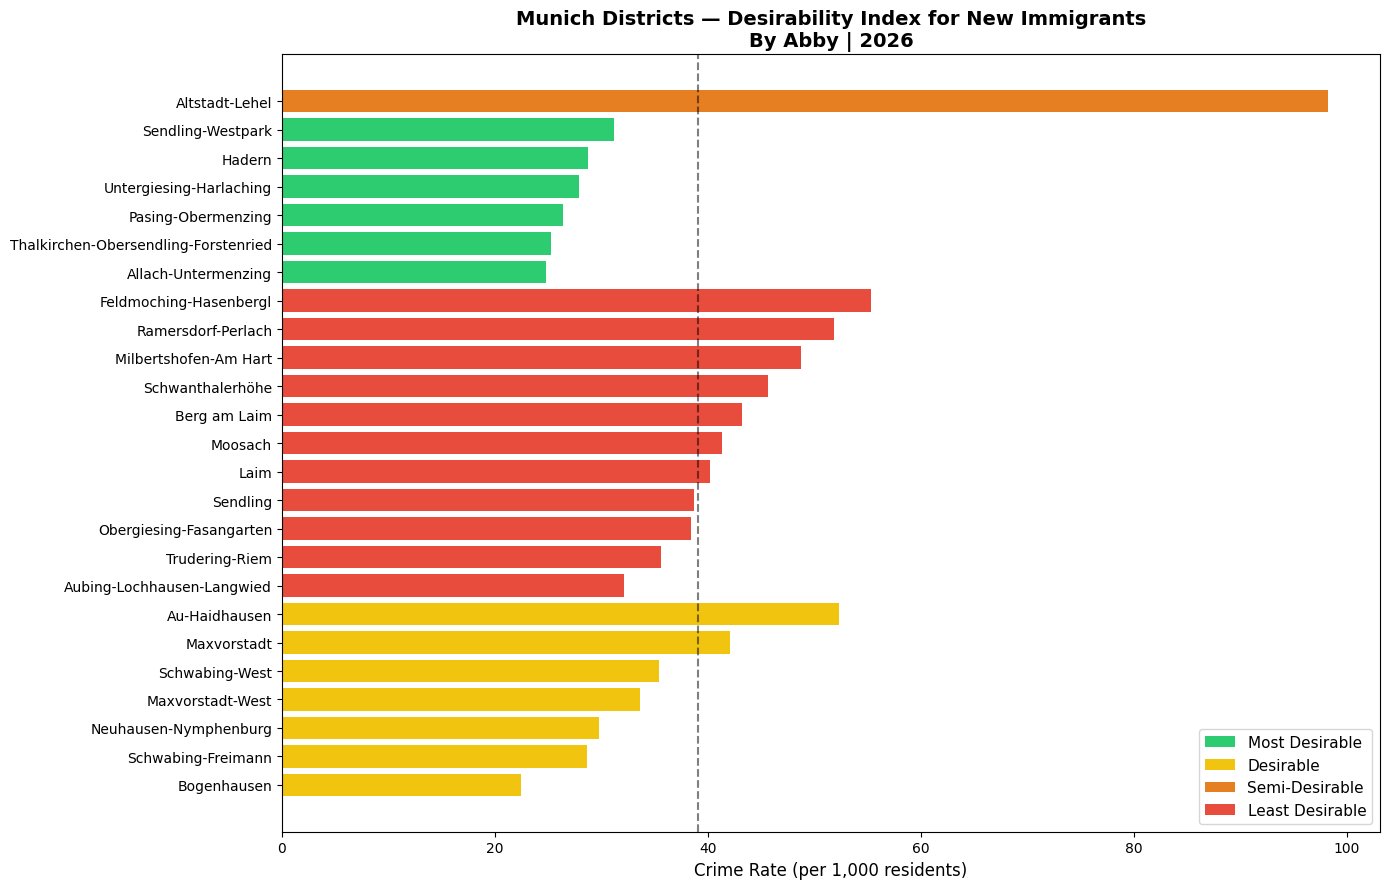


✅ Chart complete — no warnings!


In [17]:
# Clean labels without emojis
label_map_clean = {
    0: "Least Desirable",
    1: "Desirable",
    2: "Semi-Desirable",
    3: "Most Desirable"
}

district_stats["desirability_clean"] = district_stats["cluster"].map(label_map_clean)

colors_map_clean = {
    "Most Desirable": "#2ecc71",
    "Desirable": "#f1c40f",
    "Semi-Desirable": "#e67e22",
    "Least Desirable": "#e74c3c"
}

# Sort for visual grouping
plot_df = district_stats.sort_values(["desirability_clean", "crime_rate"], ascending=[True, True])
bar_colors = [colors_map_clean[d] for d in plot_df["desirability_clean"]]

fig, ax = plt.subplots(figsize=(14, 9))
ax.barh(plot_df["district_name"], plot_df["crime_rate"], color=bar_colors)

# Clean legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_map_clean.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=11)

ax.set_xlabel("Crime Rate (per 1,000 residents)", fontsize=12)
ax.set_title("Munich Districts — Desirability Index for New Immigrants\nBy Abby | 2026",
             fontsize=14, fontweight="bold")
ax.axvline(x=district_stats["crime_rate"].mean(), color="black",
           linestyle="--", alpha=0.5, label="Average crime rate")
plt.tight_layout()
plt.show()

print("\n✅ Chart complete — no warnings!")

In [19]:
import plotly.express as px

final_df = district_stats.merge(
    gdf[["district_id", "latitude", "longitude"]],
    on="district_id"
)

# Check what columns we have
print("Columns available:", final_df.columns.tolist())

Columns available: ['district_id', 'district_name', 'unemployment_rate', 'crime_rate', 'avg_rent_eur', 'cluster', 'desirability', 'desirability_clean', 'latitude', 'longitude']


In [20]:
fig = px.scatter_mapbox(
    final_df,
    lat="latitude",
    lon="longitude",
    color="desirability",          # using the original column with emojis
    size="avg_rent_eur",
    hover_name="district_name",
    hover_data={
        "unemployment_rate": True,
        "crime_rate": True,
        "avg_rent_eur": True,
        "latitude": False,
        "longitude": False
    },
    zoom=10,
    center={"lat": 48.1372, "lon": 11.5755},
    title="Munich Districts — Desirability Index for New Immigrants 2026",
    height=650
)

fig.update_layout(
    mapbox_style="open-street-map",
    title_font_size=16,
    legend_title_text="Desirability",
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig.show()
print("✅ Map generated!")

✅ Map generated!
